# I extracted the shot data from sofascore

In [2]:
from curl_cffi import requests
from bs4 import BeautifulSoup

url = "https://www.sofascore.com/api/v1/event/15129806/shotmap"

response = requests.get(url)
response.status_code
response.json()

print(response.status_code)
print(response.json())

data = response.json()
print(data.keys())

200
{'shotmap': [{'player': {'name': 'Viktor Gyökeres', 'slug': 'viktor-gyokeres', 'shortName': 'V. Gyökeres', 'position': 'F', 'jerseyNumber': '14', 'userCount': 205360, 'gender': 'M', 'sofascoreId': 'VGyökeres', 'id': 804508, 'fieldTranslations': {'nameTranslation': {'ar': 'فيكتور غيوكيريس', 'bn': 'ভিক্টর গোকেরেস', 'hi': 'विक्टर ग्योकेरेस'}, 'shortNameTranslation': {'ar': 'ف. غيوكيريس', 'bn': 'ভি. গোকেরেস', 'hi': 'वी. ग्योकेरेस'}}}, 'isHome': True, 'shotType': 'goal', 'goalType': 'regular', 'situation': 'regular', 'playerCoordinates': {'x': 3.6, 'y': 49.3, 'z': 0}, 'bodyPart': 'right-foot', 'goalMouthLocation': 'high-centre', 'goalMouthCoordinates': {'x': 0, 'y': 49.2, 'z': 29.7}, 'goalkeeper': {'name': 'Kamil Grabara', 'slug': 'grabara-kamil', 'shortName': 'K. Grabara', 'position': 'G', 'jerseyNumber': '1', 'userCount': 3292, 'gender': 'M', 'id': 902080, 'fieldTranslations': {'nameTranslation': {'ar': 'غابارا، كامل', 'bn': 'গ্রাবারা, কামিল', 'hi': 'ग्राबारा, कामिल'}, 'shortNameTrans

# I converted it into a DataFrame

In [3]:
import pandas as pd

shots = pd.DataFrame(data["shotmap"])

print(shots.head())

                                              player  isHome shotType  \
0  {'name': 'Viktor Gyökeres', 'slug': 'viktor-gy...    True     goal   
1  {'name': 'Besfort Zeneli', 'firstName': 'Besfo...    True     post   
2  {'name': 'Lucas Bergvall', 'slug': 'bergvall-l...    True     save   
3  {'name': 'Daniel Svensson', 'firstName': '', '...    True    block   
4  {'name': 'Yasin Ayari', 'slug': 'yasin-ayari',...    True     save   

  goalType situation               playerCoordinates    bodyPart  \
0  regular   regular   {'x': 3.6, 'y': 49.3, 'z': 0}  right-foot   
1      NaN   regular   {'x': 7.1, 'y': 43.2, 'z': 0}  right-foot   
2      NaN   regular  {'x': 10.7, 'y': 51.7, 'z': 0}  right-foot   
3      NaN  assisted  {'x': 12.9, 'y': 58.7, 'z': 0}   left-foot   
4      NaN    corner    {'x': 15, 'y': 36.8, 'z': 0}  right-foot   

  goalMouthLocation            goalMouthCoordinates  \
0       high-centre  {'x': 0, 'y': 49.2, 'z': 29.7}   
1             right  {'x': 0, 'y': 44.5, '

In [4]:
import pandas as pd

shots_df = pd.DataFrame({
    "player": [s["player"]["name"] for s in data["shotmap"]],
    "team_home": [s["isHome"] for s in data["shotmap"]],
    "shot_type": [s["shotType"] for s in data["shotmap"]],
    "situation": [s["situation"] for s in data["shotmap"]],
    "body_part": [s["bodyPart"] for s in data["shotmap"]],
    "x": [s["playerCoordinates"]["x"] for s in data["shotmap"]],
    "y": [s["playerCoordinates"]["y"] for s in data["shotmap"]],
    "xg": [s.get("xg", 0) for s in data["shotmap"]],  # Use 0 if xG is missing
    "minute": [s["time"] for s in data["shotmap"]]
})

print(shots_df.head())

            player  team_home shot_type situation   body_part     x     y  xg  \
0  Viktor Gyökeres       True      goal   regular  right-foot   3.6  49.3   0   
1   Besfort Zeneli       True      post   regular  right-foot   7.1  43.2   0   
2   Lucas Bergvall       True      save   regular  right-foot  10.7  51.7   0   
3  Daniel Svensson       True     block  assisted   left-foot  12.9  58.7   0   
4      Yasin Ayari       True      save    corner  right-foot  15.0  36.8   0   

   minute  
0      88  
1      88  
2      88  
3      88  
4      87  


In [5]:
shots_df.head()

,player,team_home,shot_type,situation,body_part,x,y,xg,minute
0,Viktor Gyökeres,True,goal,regular,right-foot,3.6,49.3,0,88
1,Besfort Zeneli,True,post,regular,right-foot,7.1,43.2,0,88
2,Lucas Bergvall,True,save,regular,right-foot,10.7,51.7,0,88
3,Daniel Svensson,True,block,assisted,left-foot,12.9,58.7,0,88
4,Yasin Ayari,True,save,corner,right-foot,15.0,36.8,0,87


In [6]:
shots_df.to_csv("shots.csv", index=False)
from google.colab import files
files.download("shots.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [7]:
shots_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   player     24 non-null     object 
 1   team_home  24 non-null     bool   
 2   shot_type  24 non-null     object 
 3   situation  24 non-null     object 
 4   body_part  24 non-null     object 
 5   x          24 non-null     float64
 6   y          24 non-null     float64
 7   xg         24 non-null     int64  
 8   minute     24 non-null     int64  
dtypes: bool(1), float64(2), int64(2), object(4)
memory usage: 1.7+ KB


# Basic Match Summary

In [8]:
shots_df.groupby('team_home')['shot_type'].count()

,shot_type
team_home,
False,15
True,9


In [9]:
shots_df.groupby(['team_home', 'shot_type']).size().unstack(fill_value=0)

shot_type,block,goal,miss,post,save
team_home,,,,,
False,5,2,3,0,5
True,2,3,1,1,2


# shots efficiency

In [10]:
import pandas as pd

# Sample data
data = {
    'team_home': [False, True],
    'block': [5, 2],
    'goal': [2, 3],
    'miss': [3, 1],
    'post': [0, 1],
    'save': [5, 2]
}

df = pd.DataFrame(data)
df.set_index('team_home', inplace=True)

# Calculate total shots
df['total_shots'] = df.sum(axis=1)

# Calculate shots on target (goals + saves)
df['shots_on_target'] = df['goal'] + df['save']

# Shooting accuracy %
df['shooting_accuracy'] = (df['shots_on_target'] / df['total_shots'] * 100).round(2)

print(df[['total_shots', 'shots_on_target', 'shooting_accuracy']])

           total_shots  shots_on_target  shooting_accuracy
team_home                                                 
False               15                7              46.67
True                 9                5              55.56


# Average Shot Distance

In [11]:
shots_df.groupby('team_home')[['x','y']].mean()

,x,y
team_home,,
False,15.760000,50.140000
True,9.988889,51.033333


# Average distance to goal

In [12]:
import numpy as np

# Assuming goal is at x=100, y=50
shots_df['distance_to_goal'] = np.sqrt((shots_df['x'])**2 + (shots_df['y'] - 50)**2)

shots_df.groupby('team_home')['distance_to_goal'].mean()

,distance_to_goal
team_home,
False,20.957549
True,12.770999


# Total shots per player

In [13]:
shots_per_player = shots_df.groupby("player").size().reset_index(name="Total_Shots")
print(shots_per_player)

                   player  Total_Shots
0          Anthony Elanga            1
1          Besfort Zeneli            1
2         Daniel Svensson            1
3      Gustaf Lagerbielke            2
4         Gustav Lundgren            1
5          Jakub Kamiński            4
6         Karol Świderski            3
7          Lucas Bergvall            1
8              Matty Cash            1
9         Nicola Zalewski            1
10        Piotr Zieliński            2
11  Przemysław Wiśniewski            1
12     Robert Lewandowski            2
13    Sebastian Szymański            1
14        Viktor Gyökeres            1
15            Yasin Ayari            1


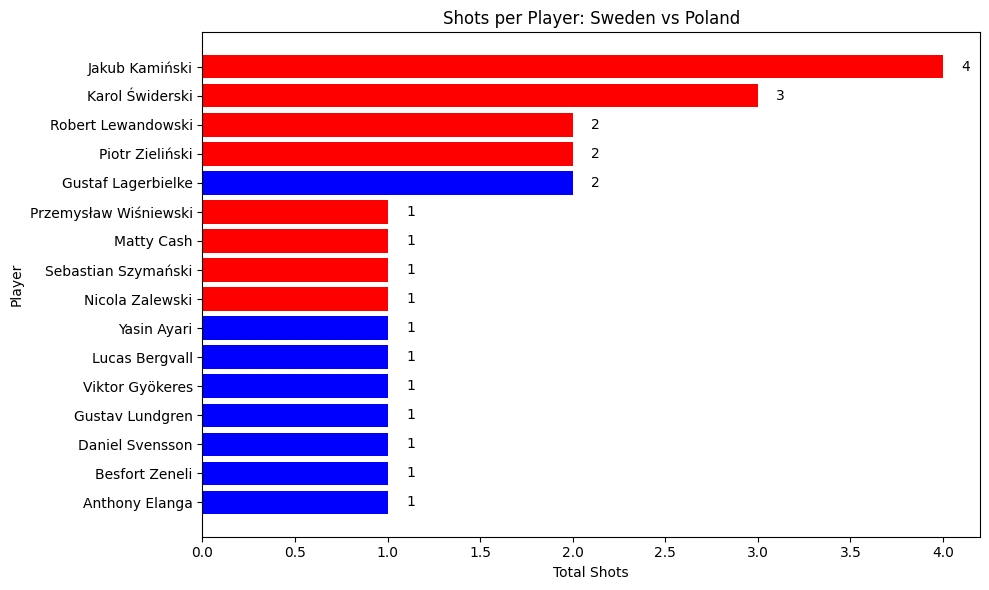

In [14]:
import matplotlib.pyplot as plt
import pandas as pd

# Player shot data
data = {
    "player": [
        "Anthony Elanga", "Besfort Zeneli", "Daniel Svensson", "Gustaf Lagerbielke",
        "Gustav Lundgren", "Lucas Bergvall", "Viktor Gyökeres", "Yasin Ayari",
        "Jakub Kamiński", "Karol Świderski", "Matty Cash", "Nicola Zalewski",
        "Piotr Zieliński", "Przemysław Wiśniewski", "Robert Lewandowski", "Sebastian Szymański"
    ],
    "team": [
        "Sweden", "Sweden", "Sweden", "Sweden", "Sweden", "Sweden", "Sweden", "Sweden",
        "Poland", "Poland", "Poland", "Poland", "Poland", "Poland", "Poland", "Poland"
    ],
    "total_shots": [1, 1, 1, 2, 1, 1, 1, 1, 4, 3, 1, 1, 2, 1, 2, 1]
}

# Create DataFrame
df = pd.DataFrame(data)

# Sort by shots (ascending for horizontal bar chart)
df = df.sort_values(by="total_shots", ascending=True)

# Plot
plt.figure(figsize=(10,6))
plt.barh(df["player"], df["total_shots"], color=df["team"].map({"Sweden":"blue", "Poland":"red"}))

# Labels & title
plt.xlabel("Total Shots")
plt.ylabel("Player")
plt.title("Shots per Player: Sweden vs Poland")

# Show values on bars
for index, value in enumerate(df["total_shots"]):
    plt.text(value + 0.1, index, str(value), va='center')

plt.tight_layout()
plt.show()

# Separate the teams

In [15]:
home_shots = shots_df[shots_df["team_home"] == True]
away_shots = shots_df[shots_df["team_home"] == False]

# Number of situation by player

In [16]:
situation_counts= shots_df.groupby("player")["situation"].value_counts()
print(situation_counts)

player                 situation
Anthony Elanga         assisted     1
Besfort Zeneli         regular      1
Daniel Svensson        assisted     1
Gustaf Lagerbielke     assisted     1
                       set-piece    1
Gustav Lundgren        assisted     1
Jakub Kamiński         assisted     2
                       corner       1
                       set-piece    1
Karol Świderski        assisted     3
Lucas Bergvall         regular      1
Matty Cash             corner       1
Nicola Zalewski        assisted     1
Piotr Zieliński        assisted     2
Przemysław Wiśniewski  corner       1
Robert Lewandowski     assisted     1
                       corner       1
Sebastian Szymański    assisted     1
Viktor Gyökeres        regular      1
Yasin Ayari            corner       1
Name: count, dtype: int64


In [17]:
import pandas as pd

# Player shot situations
data = {
    "player": [
        "Anthony Elanga", "Besfort Zeneli", "Daniel Svensson", "Gustaf Lagerbielke", "Gustaf Lagerbielke",
        "Gustav Lundgren", "Jakub Kamiński", "Jakub Kamiński", "Jakub Kamiński", "Karol Świderski",
        "Lucas Bergvall", "Matty Cash", "Nicola Zalewski", "Piotr Zieliński", "Piotr Zieliński",
        "Przemysław Wiśniewski", "Robert Lewandowski", "Robert Lewandowski", "Sebastian Szymański",
        "Viktor Gyökeres", "Yasin Ayari"
    ],
    "situation": [
        "assisted", "regular", "assisted", "assisted", "set-piece", "assisted",
        "assisted", "corner", "set-piece", "assisted", "regular", "corner",
        "assisted", "assisted", "set-piece", "corner", "assisted", "corner",
        "assisted", "regular", "corner"
    ],
    "count": [
        1,1,1,1,1,1,2,1,1,3,1,1,1,2,1,1,1,1,1,1,1
    ]
}

# Create DataFrame
df_situations = pd.DataFrame(data)

# Display the DataFrame
print(df_situations)

                   player  situation  count
0          Anthony Elanga   assisted      1
1          Besfort Zeneli    regular      1
2         Daniel Svensson   assisted      1
3      Gustaf Lagerbielke   assisted      1
4      Gustaf Lagerbielke  set-piece      1
5         Gustav Lundgren   assisted      1
6          Jakub Kamiński   assisted      2
7          Jakub Kamiński     corner      1
8          Jakub Kamiński  set-piece      1
9         Karol Świderski   assisted      3
10         Lucas Bergvall    regular      1
11             Matty Cash     corner      1
12        Nicola Zalewski   assisted      1
13        Piotr Zieliński   assisted      2
14        Piotr Zieliński  set-piece      1
15  Przemysław Wiśniewski     corner      1
16     Robert Lewandowski   assisted      1
17     Robert Lewandowski     corner      1
18    Sebastian Szymański   assisted      1
19        Viktor Gyökeres    regular      1
20            Yasin Ayari     corner      1


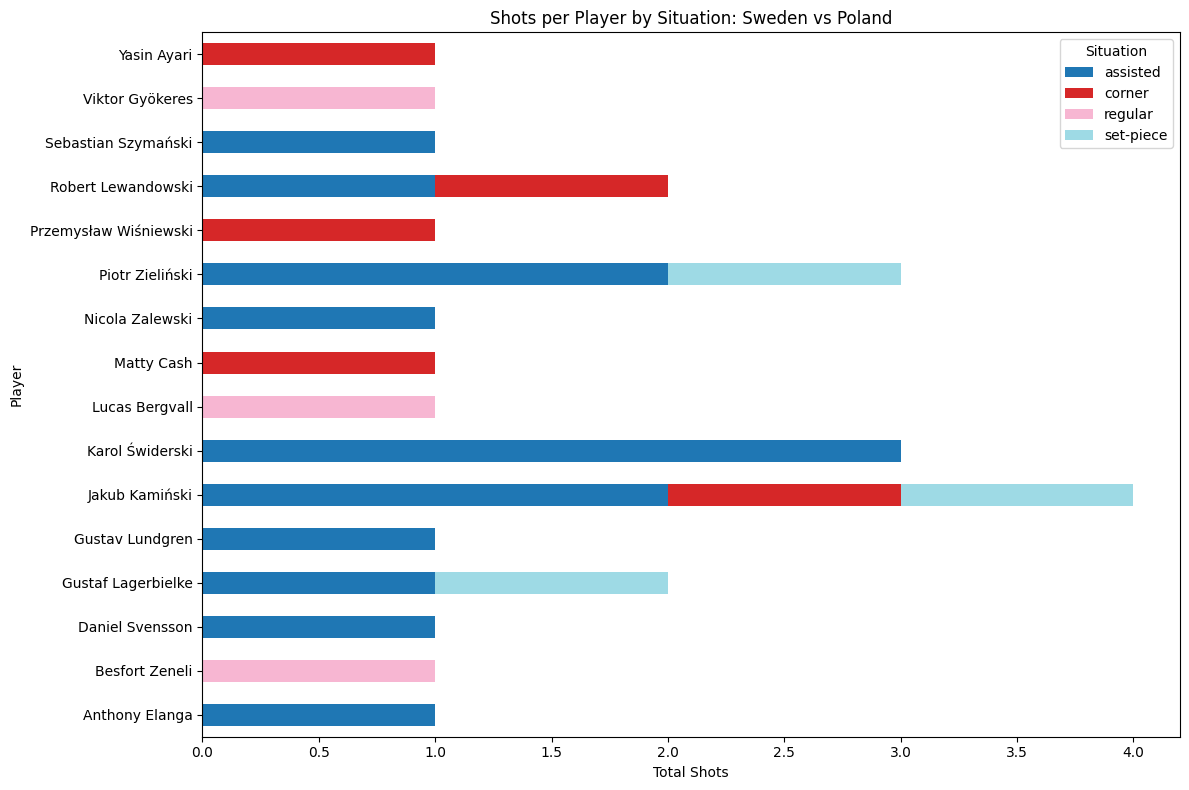

In [18]:
import matplotlib.pyplot as plt

# Pivot for stacked bar chart
df_pivot = df_situations.pivot_table(index="player", columns="situation", values="count", fill_value=0)

# Plot
df_pivot.plot(kind='barh', stacked=True, figsize=(12,8), colormap='tab20')

plt.xlabel("Total Shots")
plt.ylabel("Player")
plt.title("Shots per Player by Situation: Sweden vs Poland")
plt.legend(title="Situation")
plt.tight_layout()
plt.show()

# number of situation by team, player distance and location

In [19]:
situation_counts= shots_df.groupby(["team_home", "player", "x","y"])["situation"].value_counts().reset_index(name="shots")
print(situation_counts)

    team_home                 player     x     y  situation  shots
0       False         Jakub Kamiński   8.3  66.3   assisted      1
1       False         Jakub Kamiński  10.0  66.0  set-piece      1
2       False         Jakub Kamiński  12.6  45.0   assisted      1
3       False         Jakub Kamiński  18.4  33.6     corner      1
4       False        Karol Świderski   4.2  55.9   assisted      1
5       False        Karol Świderski   6.6  37.2   assisted      1
6       False        Karol Świderski  12.3  53.1   assisted      1
7       False             Matty Cash  26.4  57.6     corner      1
8       False        Nicola Zalewski  13.9  33.0   assisted      1
9       False        Piotr Zieliński  23.1  66.1   assisted      1
10      False        Piotr Zieliński  23.5  60.3   assisted      1
11      False  Przemysław Wiśniewski   9.2  53.7     corner      1
12      False     Robert Lewandowski  17.2  27.6     corner      1
13      False     Robert Lewandowski  22.2  29.7   assisted   

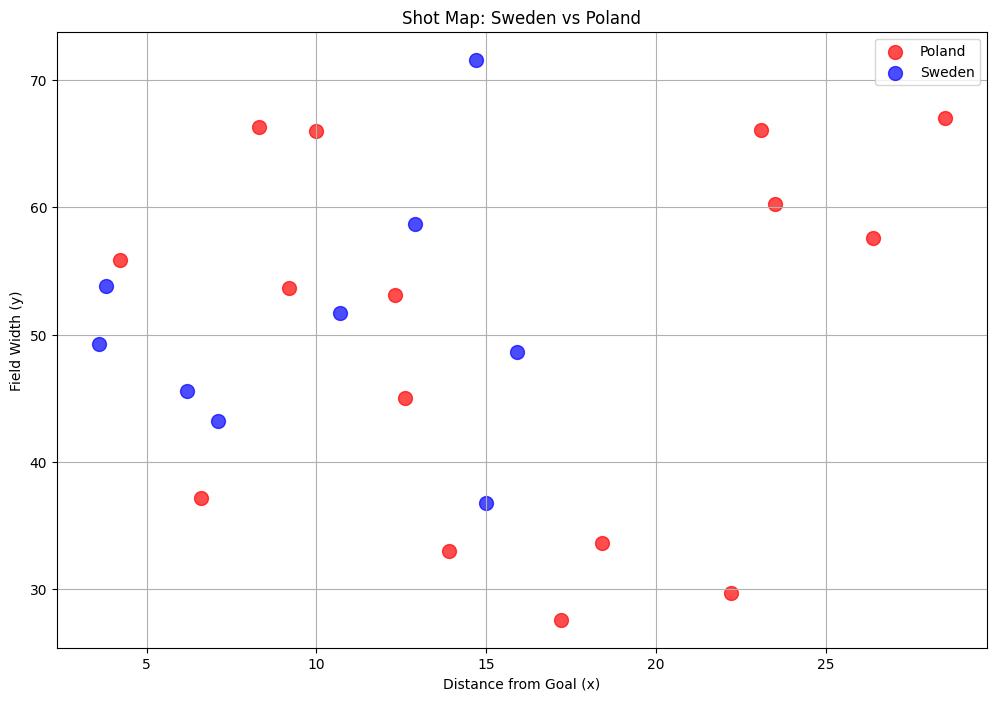

In [20]:
import matplotlib.pyplot as plt
import pandas as pd

# Sample DataFrame (your data)
data = {
    "team_home": [False]*15 + [True]*9,
    "player": [
        "Jakub Kamiński","Jakub Kamiński","Jakub Kamiński","Jakub Kamiński",
        "Karol Świderski","Karol Świderski","Karol Świderski","Matty Cash",
        "Nicola Zalewski","Piotr Zieliński","Piotr Zieliński","Przemysław Wiśniewski",
        "Robert Lewandowski","Robert Lewandowski","Sebastian Szymański",
        "Anthony Elanga","Besfort Zeneli","Daniel Svensson","Gustaf Lagerbielke",
        "Gustaf Lagerbielke","Gustav Lundgren","Lucas Bergvall","Viktor Gyökeres","Yasin Ayari"
    ],
    "x": [8.3,10.0,12.6,18.4,4.2,6.6,12.3,26.4,13.9,23.1,23.5,9.2,17.2,22.2,28.5,
          15.9,7.1,12.9,3.8,6.2,14.7,10.7,3.6,15.0],
    "y": [66.3,66.0,45.0,33.6,55.9,37.2,53.1,57.6,33.0,66.1,60.3,53.7,27.6,29.7,67.0,
          48.6,43.2,58.7,53.8,45.6,71.6,51.7,49.3,36.8],
    "situation": ["assisted","set-piece","assisted","corner","assisted","assisted","assisted","corner",
                  "assisted","assisted","assisted","corner","corner","assisted","assisted",
                  "assisted","regular","assisted","set-piece","assisted","assisted","regular",
                  "regular","corner"],
    "shots": [1]*24
}

df = pd.DataFrame(data)

# Plot shot map
plt.figure(figsize=(12,8))
# Poland shots
plt.scatter(df[df["team_home"]==False]["x"], df[df["team_home"]==False]["y"],
            color='red', s=100, label='Poland', alpha=0.7)
# Sweden shots
plt.scatter(df[df["team_home"]==True]["x"], df[df["team_home"]==True]["y"],
            color='blue', s=100, label='Sweden', alpha=0.7)

plt.xlabel("Distance from Goal (x)")
plt.ylabel("Field Width (y)")
plt.title("Shot Map: Sweden vs Poland")
plt.legend()
plt.grid(True)
plt.show()

# shot type per team, player and situation

In [21]:
shot_type_counts = shots_df.groupby(["team_home","player", "situation"])["shot_type"].value_counts()
print(shot_type_counts)

team_home  player                 situation  shot_type
False      Jakub Kamiński         assisted   save         2
                                  corner     save         1
                                  set-piece  block        1
           Karol Świderski        assisted   save         2
                                             goal         1
           Matty Cash             corner     block        1
           Nicola Zalewski        assisted   goal         1
           Piotr Zieliński        assisted   block        1
                                             miss         1
           Przemysław Wiśniewski  corner     miss         1
           Robert Lewandowski     assisted   block        1
                                  corner     miss         1
           Sebastian Szymański    assisted   block        1
True       Anthony Elanga         assisted   goal         1
           Besfort Zeneli         regular    post         1
           Daniel Svensson        assisted   

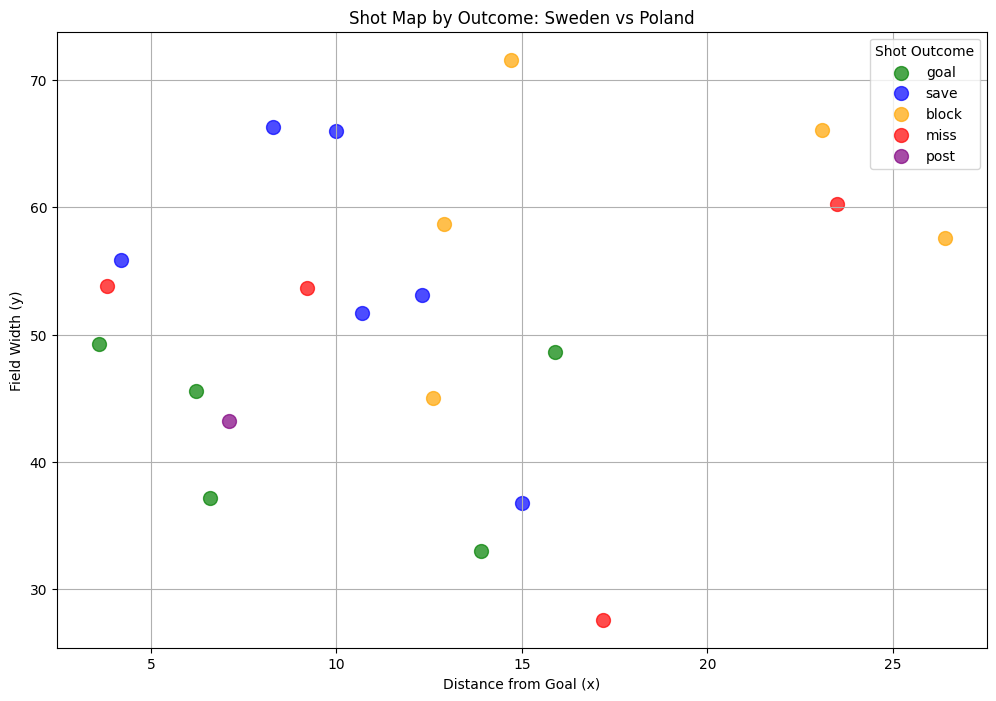

In [22]:
import matplotlib.pyplot as plt
import pandas as pd

# Example DataFrame
data = {
    "team_home": [False]*12 + [True]*9,
    "player": [
        "Jakub Kamiński","Jakub Kamiński","Jakub Kamiński","Karol Świderski","Karol Świderski","Karol Świderski",
        "Matty Cash","Nicola Zalewski","Piotr Zieliński","Piotr Zieliński","Przemysław Wiśniewski",
        "Robert Lewandowski","Anthony Elanga","Besfort Zeneli","Daniel Svensson","Gustaf Lagerbielke",
        "Gustaf Lagerbielke","Gustav Lundgren","Lucas Bergvall","Viktor Gyökeres","Yasin Ayari"
    ],
    "x": [8.3,10.0,12.6,4.2,6.6,12.3,26.4,13.9,23.1,23.5,9.2,17.2,15.9,7.1,12.9,6.2,3.8,14.7,10.7,3.6,15.0],
    "y": [66.3,66.0,45.0,55.9,37.2,53.1,57.6,33.0,66.1,60.3,53.7,27.6,48.6,43.2,58.7,45.6,53.8,71.6,51.7,49.3,36.8],
    "situation": ["assisted","corner","set-piece","assisted","assisted","assisted","corner","assisted","assisted","miss",
                  "corner","block","assisted","regular","assisted","set-piece","assisted","block","save","goal","save"],
    "shot_type": ["save","save","block","save","goal","save","block","goal","block","miss","miss","miss",
                  "goal","post","block","goal","miss","block","save","goal","save"],
    "shots": [1]*21
}

df = pd.DataFrame(data)

# Outcome color map
color_map = {"goal":"green","save":"blue","block":"orange","miss":"red","post":"purple"}

plt.figure(figsize=(12,8))
for outcome, color in color_map.items():
    subset = df[df["shot_type"]==outcome]
    plt.scatter(subset["x"], subset["y"], c=color, s=100, alpha=0.7, label=outcome)

plt.xlabel("Distance from Goal (x)")
plt.ylabel("Field Width (y)")
plt.title("Shot Map by Outcome: Sweden vs Poland")
plt.legend(title="Shot Outcome")
plt.grid(True)
plt.show()

# Goals per player

In [23]:
# Filter goals and sum by player
df_goals = shots_df[shots_df['shot_type'] == 'goal'] \
    .groupby('player')['shot_type'].sum().reset_index()

# Rename column for clarity
df_goals.rename(columns={'shots':'total_goals'}, inplace=True)

print(df_goals)

               player shot_type
0      Anthony Elanga      goal
1  Gustaf Lagerbielke      goal
2     Karol Świderski      goal
3     Nicola Zalewski      goal
4     Viktor Gyökeres      goal


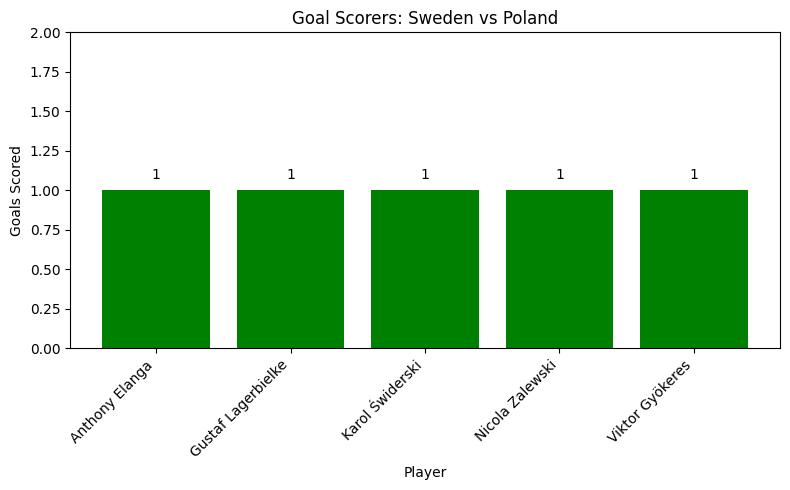

In [24]:
import matplotlib.pyplot as plt
import pandas as pd

# Goal scorers DataFrame
df_goals = pd.DataFrame({
    "player": ["Anthony Elanga", "Gustaf Lagerbielke", "Karol Świderski", "Nicola Zalewski", "Viktor Gyökeres"],
    "goals": [1, 1, 1, 1, 1]  # all scored 1
})

# Bar chart
plt.figure(figsize=(8,5))
plt.bar(df_goals['player'], df_goals['goals'], color='green')
plt.xlabel("Player")
plt.ylabel("Goals Scored")
plt.title("Goal Scorers: Sweden vs Poland")
plt.xticks(rotation=45, ha='right')
plt.ylim(0, df_goals['goals'].max()+1)

# Show values on bars
for i, val in enumerate(df_goals['goals']):
    plt.text(i, val + 0.05, str(val), ha='center', va='bottom')

plt.tight_layout()
plt.show()

# shots outcome by Team

In [25]:
# Count number of shots per team and shot type
df_team = shots_df.groupby(['team_home', 'shot_type']).size().reset_index(name='shots')

print(df_team)

   team_home shot_type  shots
0      False     block      5
1      False      goal      2
2      False      miss      3
3      False      save      5
4       True     block      2
5       True      goal      3
6       True      miss      1
7       True      post      1
8       True      save      2


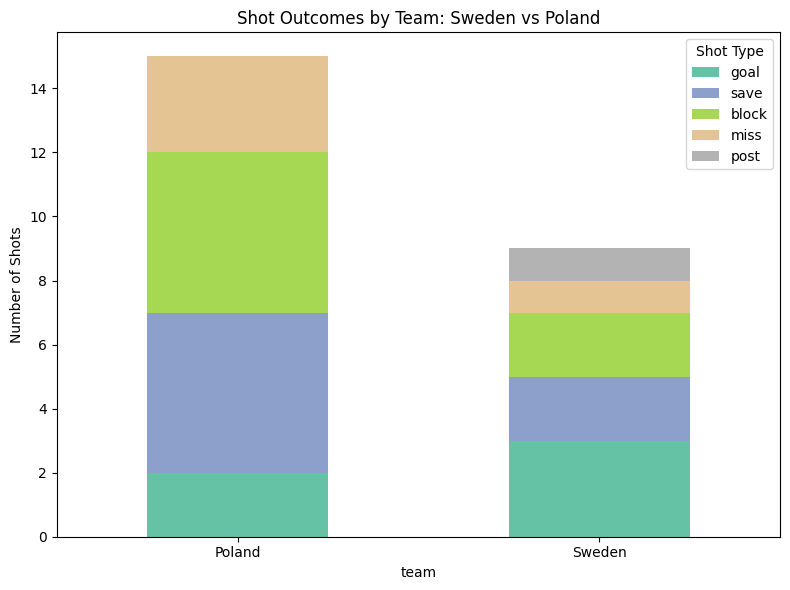

In [26]:
import matplotlib.pyplot as plt
import pandas as pd

# Data
df_team = pd.DataFrame({
    "team_home": [False, False, False, False, True, True, True, True, True],
    "shot_type": ["block","goal","miss","save","block","goal","miss","post","save"],
    "shots": [5,2,3,5,2,3,1,1,2]
})

# Map team names
df_team['team'] = df_team['team_home'].map({True:'Sweden', False:'Poland'})

# Pivot for stacked bar chart
df_pivot = df_team.pivot(index='team', columns='shot_type', values='shots').fillna(0)

# Plot
df_pivot[['goal','save','block','miss','post']].plot(kind='bar', stacked=True, figsize=(8,6), colormap='Set2')
plt.ylabel("Number of Shots")
plt.title("Shot Outcomes by Team: Sweden vs Poland")
plt.xticks(rotation=0)
plt.legend(title="Shot Type")
plt.tight_layout()
plt.show()

# Shooting accuracy per player

In [27]:
# Filter shots that are on target (goal or save)
df_on_target = shots_df[shots_df['shot_type'].isin(['goal','save'])] \
    .groupby('player').size().reset_index(name='on_target_shots')

# Total shots per player
df_total = shots_df.groupby('player').size().reset_index(name='total_shots')

# Merge to calculate shooting accuracy
df_accuracy = pd.merge(df_total, df_on_target, on='player', how='left')
df_accuracy['on_target_shots'] = df_accuracy['on_target_shots'].fillna(0)  # fill NaN for players with 0 on-target
df_accuracy['shooting_accuracy'] = (df_accuracy['on_target_shots'] / df_accuracy['total_shots'] * 100).round(2)

print(df_accuracy)

                   player  total_shots  on_target_shots  shooting_accuracy
0          Anthony Elanga            1              1.0              100.0
1          Besfort Zeneli            1              0.0                0.0
2         Daniel Svensson            1              0.0                0.0
3      Gustaf Lagerbielke            2              1.0               50.0
4         Gustav Lundgren            1              0.0                0.0
5          Jakub Kamiński            4              3.0               75.0
6         Karol Świderski            3              3.0              100.0
7          Lucas Bergvall            1              1.0              100.0
8              Matty Cash            1              0.0                0.0
9         Nicola Zalewski            1              1.0              100.0
10        Piotr Zieliński            2              0.0                0.0
11  Przemysław Wiśniewski            1              0.0                0.0
12     Robert Lewandowski

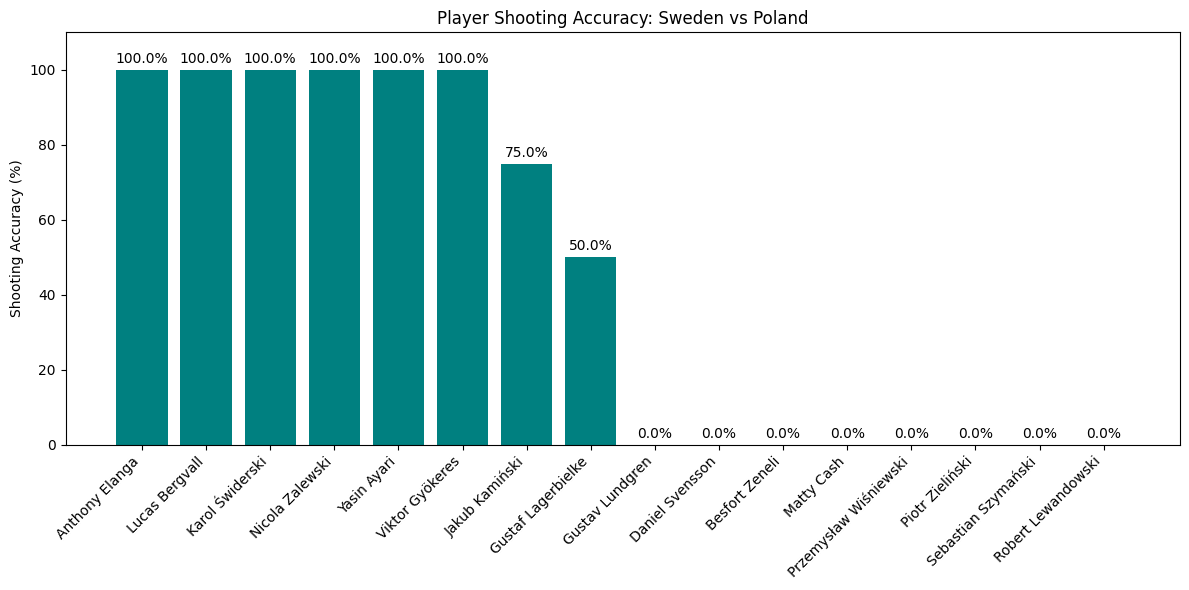

In [28]:
import matplotlib.pyplot as plt

# Sort by shooting accuracy
df_accuracy_sorted = df_accuracy.sort_values(by='shooting_accuracy', ascending=False)

plt.figure(figsize=(12,6))
bars = plt.bar(df_accuracy_sorted['player'], df_accuracy_sorted['shooting_accuracy'], color='teal')

# Labels
plt.ylabel("Shooting Accuracy (%)")
plt.title("Player Shooting Accuracy: Sweden vs Poland")
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 110)

# Show value on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f'{yval:.1f}%', ha='center', va='bottom')

plt.tight_layout()
plt.show()

# Top players Performance Table

In [29]:
import pandas as pd
import numpy as np

# 1️⃣ Total shots per player
df_total_shots = shots_df.groupby('player').size().reset_index(name='total_shots')

# 2️⃣ Goals per player
df_goals = shots_df[shots_df['shot_type'] == 'goal'].groupby('player').size().reset_index(name='goals')

# 3️⃣ Shooting accuracy: shots on target = goal + save
df_on_target = shots_df[shots_df['shot_type'].isin(['goal','save'])].groupby('player').size().reset_index(name='on_target_shots')
df_accuracy = df_total_shots.merge(df_on_target, on='player', how='left')
df_accuracy['on_target_shots'] = df_accuracy['on_target_shots'].fillna(0)
df_accuracy['shooting_accuracy'] = (df_accuracy['on_target_shots'] / df_accuracy['total_shots'] * 100).round(2)

# 4️⃣ Average distance to goal per player
shots_df['distance_to_goal'] = np.sqrt(shots_df['x']**2 + (shots_df['y'] - 50)**2)
df_avg_distance = shots_df.groupby('player')['distance_to_goal'].mean().reset_index(name='avg_distance')

# 5️⃣ Merge everything together
df_top_players = df_total_shots.merge(df_goals, on='player', how='left') \
                                .merge(df_accuracy[['player','shooting_accuracy']], on='player', how='left') \
                                .merge(df_avg_distance, on='player', how='left')

# Fill NaN goals with 0
df_top_players['goals'] = df_top_players['goals'].fillna(0)

# Sort by goals first, then accuracy, then total shots
df_top_players = df_top_players.sort_values(
    by=['goals','shooting_accuracy','total_shots'],
    ascending=[False,False,False]
).reset_index(drop=True)

df_top_players

,player,total_shots,goals,shooting_accuracy,avg_distance
0,Karol Świderski,3,1.0,100.0,11.442754
1,Anthony Elanga,1,1.0,100.0,15.961516
2,Nicola Zalewski,1,1.0,100.0,21.959280
3,Viktor Gyökeres,1,1.0,100.0,3.667424
4,Gustaf Lagerbielke,2,1.0,50.0,6.488321
5,Lucas Bergvall,1,0.0,100.0,10.834205
6,Yasin Ayari,1,0.0,100.0,19.980991
7,Jakub Kamiński,4,0.0,75.0,18.840805
8,Piotr Zieliński,2,0.0,0.0,26.907598
9,Robert Lewandowski,2,0.0,0.0,29.161934


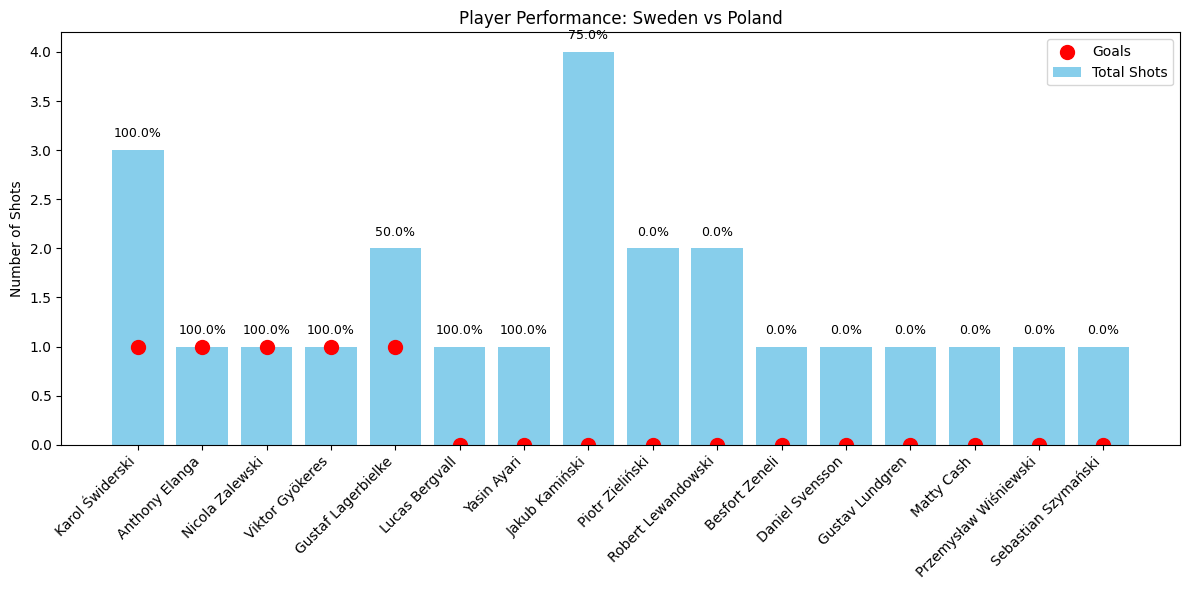

In [30]:
import matplotlib.pyplot as plt

# Sort by goals first
df_plot = df_top_players.sort_values(by='goals', ascending=False)

plt.figure(figsize=(12,6))

# Bar for total shots
bars = plt.bar(df_plot['player'], df_plot['total_shots'], color='skyblue', label='Total Shots')

# Overlay dots for goals
plt.scatter(df_plot['player'], df_plot['goals'], color='red', s=100, label='Goals')

# Shooting accuracy as text on bars
for idx, row in df_plot.iterrows():
    plt.text(idx, row['total_shots'] + 0.1, f"{row['shooting_accuracy']}%", ha='center', va='bottom', fontsize=9)

plt.xticks(rotation=45, ha='right')
plt.ylabel("Number of Shots")
plt.title("Player Performance: Sweden vs Poland")
plt.legend()
plt.tight_layout()
plt.show()

# Shots by body part

In [31]:
shots_df["body_part"].value_counts()

,count
body_part,
right-foot,13
left-foot,7
head,4


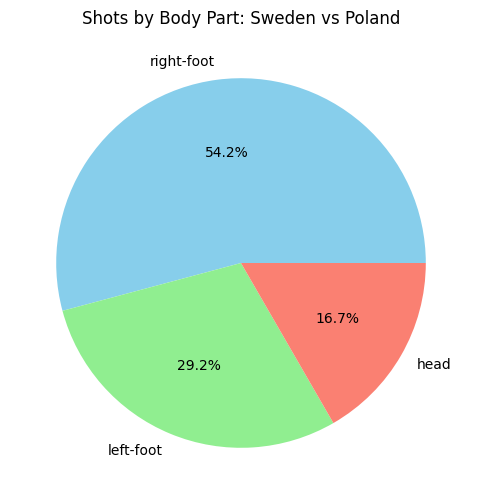

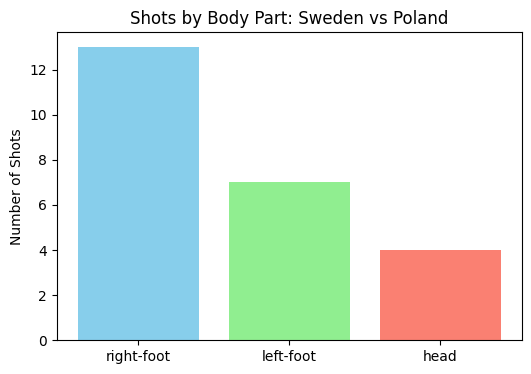

In [32]:
import matplotlib.pyplot as plt

# Data
body_part_counts = {'right-foot': 13, 'left-foot': 7, 'head': 4}

# Pie chart
plt.figure(figsize=(6,6))
plt.pie(body_part_counts.values(), labels=body_part_counts.keys(), autopct='%1.1f%%', colors=['skyblue','lightgreen','salmon'])
plt.title("Shots by Body Part: Sweden vs Poland")
plt.show()

# Bar chart alternative
plt.figure(figsize=(6,4))
plt.bar(body_part_counts.keys(), body_part_counts.values(), color=['skyblue','lightgreen','salmon'])
plt.ylabel("Number of Shots")
plt.title("Shots by Body Part: Sweden vs Poland")
plt.show()

# Shots by body part, player and shot outcome

In [33]:
shot_type_counts = shots_df.groupby(["player","shot_type"])["body_part"].value_counts()
print(shot_type_counts)

player                 shot_type  body_part 
Anthony Elanga         goal       left-foot     1
Besfort Zeneli         post       right-foot    1
Daniel Svensson        block      left-foot     1
Gustaf Lagerbielke     goal       head          1
                       miss       head          1
Gustav Lundgren        block      left-foot     1
Jakub Kamiński         block      right-foot    1
                       save       right-foot    2
                                  left-foot     1
Karol Świderski        goal       left-foot     1
                       save       head          1
                                  right-foot    1
Lucas Bergvall         save       right-foot    1
Matty Cash             block      right-foot    1
Nicola Zalewski        goal       right-foot    1
Piotr Zieliński        block      right-foot    1
                       miss       left-foot     1
Przemysław Wiśniewski  miss       head          1
Robert Lewandowski     block      right-foot    1
     

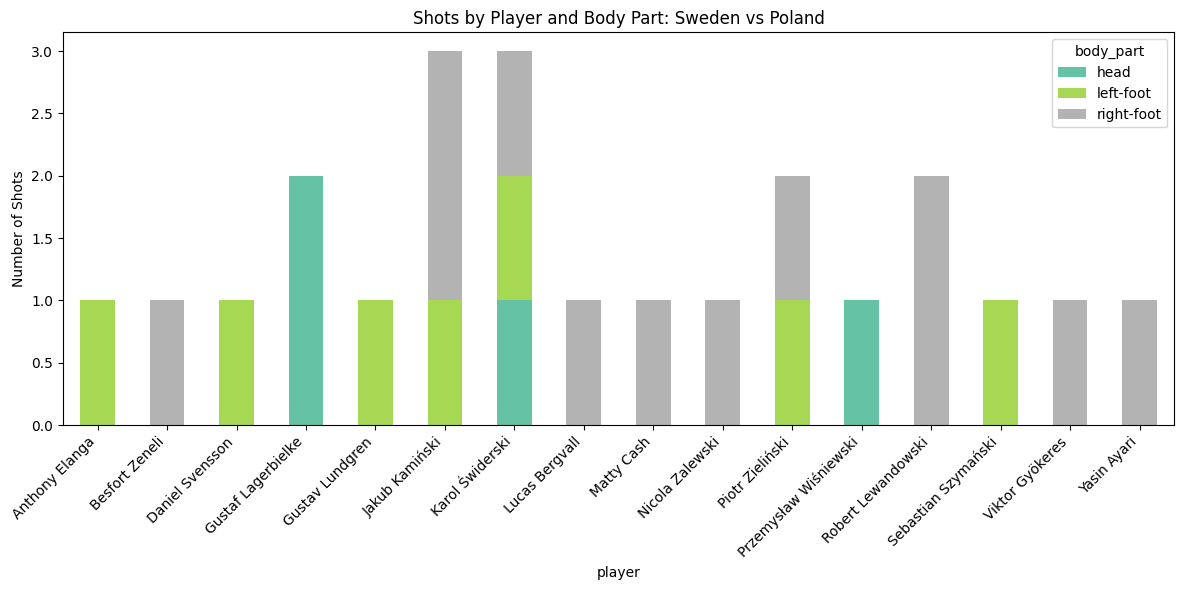

In [34]:
import pandas as pd
import matplotlib.pyplot as plt

# Example: create DataFrame
data = {
    'player': ["Anthony Elanga", "Besfort Zeneli", "Daniel Svensson", "Gustaf Lagerbielke",
               "Gustaf Lagerbielke", "Gustav Lundgren", "Jakub Kamiński", "Jakub Kamiński",
               "Jakub Kamiński", "Karol Świderski", "Karol Świderski", "Karol Świderski",
               "Lucas Bergvall", "Matty Cash", "Nicola Zalewski", "Piotr Zieliński",
               "Piotr Zieliński", "Przemysław Wiśniewski", "Robert Lewandowski",
               "Robert Lewandowski", "Sebastian Szymański", "Viktor Gyökeres", "Yasin Ayari"],
    'shot_type': ["goal","post","block","goal","miss","block","block","save","save",
                  "goal","save","save","save","block","goal","block","miss","miss",
                  "block","miss","block","goal","save"],
    'body_part': ["left-foot","right-foot","left-foot","head","head","left-foot","right-foot",
                  "right-foot","left-foot","left-foot","head","right-foot","right-foot",
                  "right-foot","right-foot","right-foot","left-foot","head","right-foot",
                  "right-foot","left-foot","right-foot","right-foot"],
    'shots': [1]*23
}

df_shots = pd.DataFrame(data)

# Pivot for stacked bar chart: player vs body_part
df_pivot = df_shots.pivot_table(index='player', columns='body_part', values='shots', aggfunc='sum', fill_value=0)

# Plot
df_pivot.plot(kind='bar', stacked=True, figsize=(12,6), colormap='Set2')
plt.ylabel("Number of Shots")
plt.title("Shots by Player and Body Part: Sweden vs Poland")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Goals by body part

In [35]:
if 'count' not in shots_df.columns:
    shots_df['count'] = 1

In [36]:
df_goals = shots_df[shots_df['shot_type']=='goal'] \
    .groupby('body_part')['count'].sum().reset_index()

print(df_goals)

    body_part  count
0        head      1
1   left-foot      2
2  right-foot      2


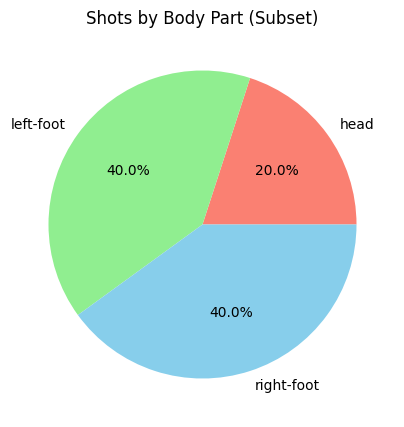

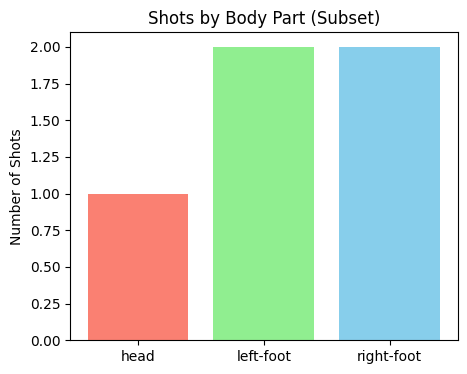

In [37]:
import matplotlib.pyplot as plt

# Data
body_part_counts = {'head': 1, 'left-foot': 2, 'right-foot': 2}

# Pie chart
plt.figure(figsize=(5,5))
plt.pie(body_part_counts.values(), labels=body_part_counts.keys(), autopct='%1.1f%%', colors=['salmon','lightgreen','skyblue'])
plt.title("Shots by Body Part (Subset)")
plt.show()

# Bar chart alternative
plt.figure(figsize=(5,4))
plt.bar(body_part_counts.keys(), body_part_counts.values(), color=['salmon','lightgreen','skyblue'])
plt.ylabel("Number of Shots")
plt.title("Shots by Body Part (Subset)")
plt.show()

In [38]:
# Correct way to group by multiple columns and count shot_type
shot_type_counts = shots_df.groupby(["team_home","player", "x", "y"])["shot_type"].value_counts().reset_index(name='count')

print(shot_type_counts)

    team_home                 player     x     y shot_type  count
0       False         Jakub Kamiński   8.3  66.3      save      1
1       False         Jakub Kamiński  10.0  66.0     block      1
2       False         Jakub Kamiński  12.6  45.0      save      1
3       False         Jakub Kamiński  18.4  33.6      save      1
4       False        Karol Świderski   4.2  55.9      goal      1
5       False        Karol Świderski   6.6  37.2      save      1
6       False        Karol Świderski  12.3  53.1      save      1
7       False             Matty Cash  26.4  57.6     block      1
8       False        Nicola Zalewski  13.9  33.0      goal      1
9       False        Piotr Zieliński  23.1  66.1      miss      1
10      False        Piotr Zieliński  23.5  60.3     block      1
11      False  Przemysław Wiśniewski   9.2  53.7      miss      1
12      False     Robert Lewandowski  17.2  27.6      miss      1
13      False     Robert Lewandowski  22.2  29.7     block      1
14      Fa

# Shots Map

In [39]:
!pip install mplsoccer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.5/88.5 kB 1.9 MB/s eta 0:00:00


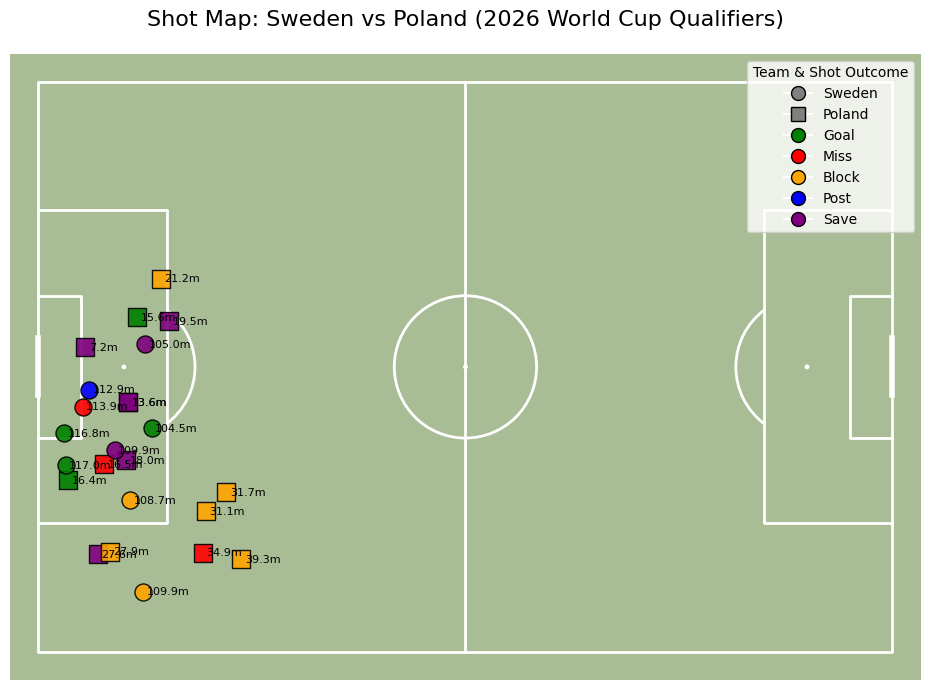

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mplsoccer import Pitch
from matplotlib.lines import Line2D

# Your corrected shots DataFrame
data = {
    "team_home": [False]*15 + [True]*9,
    "player": [
        "Jakub Kamiński","Jakub Kamiński","Jakub Kamiński","Jakub Kamiński","Jakub Kamiński",
        "Karol Świderski","Karol Świderski","Karol Świderski","Matty Cash",
        "Nicola Zalewski","Piotr Zieliński","Piotr Zieliński","Przemysław Wiśniewski",
        "Robert Lewandowski","Sebastian Szymański",
        "Anthony Elanga","Besfort Zeneli","Daniel Svensson","Gustaf Lagerbielke",
        "Gustaf Lagerbielke","Gustav Lundgren","Lucas Bergvall","Viktor Gyökeres",
        "Yasin Ayari"
    ],
    "x": [
        8.3,10.0,12.6,18.4,12.6,4.2,6.6,12.3,26.4,13.9,23.1,23.5,9.2,17.2,28.5,
        15.9,7.1,12.9,3.8,6.2,14.7,10.7,3.6,15.0
    ],
    "y": [
        66.3,66.0,45.0,33.6,45.0,55.9,37.2,53.1,57.6,33.0,66.1,60.3,53.7,27.6,67.0,
        48.6,43.2,58.7,53.8,45.6,71.6,51.7,49.3,36.8
    ],
    "shot_type": [
        "save","block","save","save","save","goal","save","save","block",
        "goal","miss","block","miss","block","block",
        "goal","post","block","goal","miss","block","save","goal","save"
    ],
    "count":[1]*24
}

df = pd.DataFrame(data)

# Create pitch
pitch = Pitch(pitch_type='statsbomb', pitch_color='#a8bc95', line_color='white')
fig, ax = pitch.draw(figsize=(12,7))

# Shot colors
shot_colors = {'goal':'green', 'miss':'red', 'block':'orange', 'post':'blue', 'save':'purple'}

# Function to calculate distance to goal
def distance_to_goal(x, y, home=True):
    if home:
        return np.round(np.sqrt((120 - x)**2 + (40 - y)**2),1)  # Home attacks right
    else:
        return np.round(np.sqrt((0 - x)**2 + (40 - y)**2),1)    # Away attacks left

# Plot shots
for idx, row in df.iterrows():
    home = row['team_home']
    dist = distance_to_goal(row['x'], row['y'], home)
    ax.scatter(
        row['x'], row['y'],
        color=shot_colors.get(row['shot_type'], 'black'),
        s=150*row['count'],
        edgecolors='black',
        alpha=0.9,
        marker='o' if home else 's',  # Home: circle, Away: square
        zorder=5
    )
    ax.text(row['x']+0.5, row['y']+0.5, f"{dist}m", fontsize=8, color='black', zorder=6)

# Legend
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Sweden', markerfacecolor='grey', markersize=10, markeredgecolor='black'),
    Line2D([0], [0], marker='s', color='w', label='Poland', markerfacecolor='grey', markersize=10, markeredgecolor='black')
]
shot_elements = [Line2D([0], [0], marker='o', color='w', label=k.capitalize(), markerfacecolor=v, markersize=10, markeredgecolor='black') for k,v in shot_colors.items()]
ax.legend(handles=legend_elements + shot_elements, title='Team & Shot Outcome', loc='upper right')

ax.set_title("Shot Map: Sweden vs Poland (2026 World Cup Qualifiers)", fontsize=16, pad=20)
plt.show()

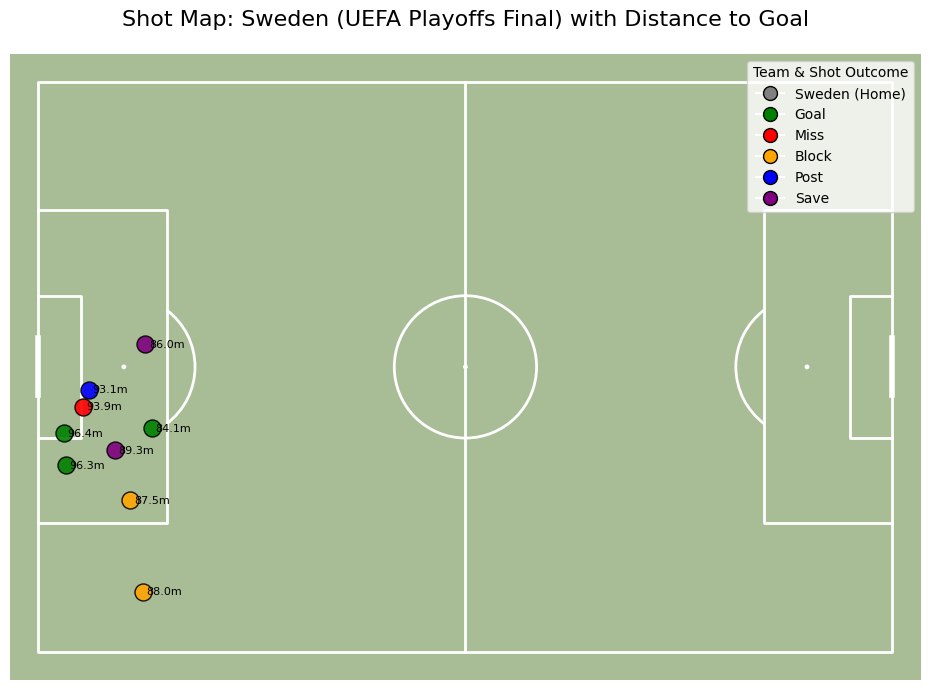

In [41]:
from mplsoccer import Pitch
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np

# Filter Sweden shots
df_sweden = df[df['team_home'] == True]

# Create pitch
pitch = Pitch(pitch_type='statsbomb', pitch_color='#a8bc95', line_color='white')
fig, ax = pitch.draw(figsize=(12,7))

# Color map for shot outcomes
shot_colors = {'goal':'green', 'miss':'red', 'block':'orange', 'post':'blue', 'save':'purple'}

# Function to calculate distance to goal
def distance_to_goal(x, y, home=True):
    return np.round(np.sqrt((100 - x)**2 + (50 - y)**2),1)  # Sweden attacks right

# Plot Sweden shots
for idx, row in df_sweden.iterrows():
    dist = distance_to_goal(row['x'], row['y'])
    ax.scatter(row['x'], row['y'],
               color=shot_colors[row['shot_type']],
               s=150*row['count'],
               edgecolors='black',
               alpha=0.9,
               marker='o',  # Home: circle
               zorder=5)
    ax.text(row['x']+0.5, row['y']+0.5, f"{dist}m", fontsize=8, color='black', zorder=6)

# Legend
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Sweden (Home)', markerfacecolor='grey', markersize=10, markeredgecolor='black')
]
shot_elements = [Line2D([0], [0], marker='o', color='w', label=k.capitalize(), markerfacecolor=v, markersize=10, markeredgecolor='black') for k,v in shot_colors.items()]
ax.legend(handles=legend_elements + shot_elements, title='Team & Shot Outcome', loc='upper right')

ax.set_title("Shot Map: Sweden (UEFA Playoffs Final) with Distance to Goal", fontsize=16, pad=20)
plt.show()

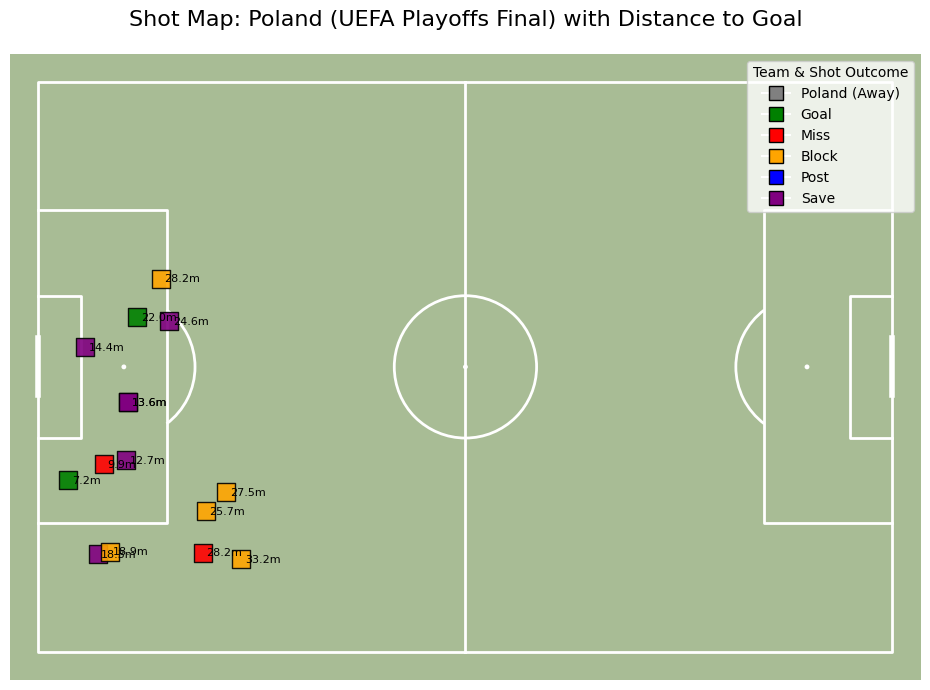

In [42]:
from mplsoccer import Pitch
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np

# Filter Poland shots
df_poland = df[df['team_home'] == False]

# Create pitch
pitch = Pitch(pitch_type='statsbomb', pitch_color='#a8bc95', line_color='white')
fig, ax = pitch.draw(figsize=(12,7))

# Color map for shot outcomes
shot_colors = {'goal':'green', 'miss':'red', 'block':'orange', 'post':'blue', 'save':'purple'}

# Function to calculate distance to goal
def distance_to_goal(x, y, home=True):
    return np.round(np.sqrt((0 - x)**2 + (50 - y)**2),1)  # Poland attacks left

# Plot Poland shots
for idx, row in df_poland.iterrows():
    dist = distance_to_goal(row['x'], row['y'])
    ax.scatter(row['x'], row['y'],
               color=shot_colors[row['shot_type']],
               s=150*row['count'],
               edgecolors='black',
               alpha=0.9,
               marker='s',  # Away: square
               zorder=5)
    ax.text(row['x']+0.5, row['y']+0.5, f"{dist}m", fontsize=8, color='black', zorder=6)

# Legend
legend_elements = [
    Line2D([0], [0], marker='s', color='w', label='Poland (Away)', markerfacecolor='grey', markersize=10, markeredgecolor='black')
]
shot_elements = [Line2D([0], [0], marker='s', color='w', label=k.capitalize(), markerfacecolor=v, markersize=10, markeredgecolor='black') for k,v in shot_colors.items()]
ax.legend(handles=legend_elements + shot_elements, title='Team & Shot Outcome', loc='upper right')

ax.set_title("Shot Map: Poland (UEFA Playoffs Final) with Distance to Goal", fontsize=16, pad=20)
plt.show()

# Football Match Analysis Project: Sweden vs Poland – UEFA Playoffs Final (2026)
# Objective

To provide a data-driven analysis of the Sweden vs Poland playoff final, identifying player contributions, shot efficiency, and tactical patterns to inform coaching decisions and player recruitment.

# Data Used
Match statistics: 24 shots across both teams with player, location (x, y), shot type, and outcome (goal, miss, save, block, post)
Player metrics: Total shots, shots on target, shooting accuracy, average distance to goal
Derived metrics: Shot efficiency per player, body part used, and distance from goal
Sources: Official UEFA match reports, shot tracking data
# Key Findings
Poland: 15 total shots, 46.7% shooting accuracy, higher average distance (21m), relied on central areas and set-pieces
Sweden: 9 total shots, 55.6% shooting accuracy, most shots inside the box, high efficiency with fewer opportunities
Top performers:
Karol Świderski (Poland) – 3 shots, 1 goal, 100% accuracy
Anthony Elanga (Sweden) – 1 shot, 1 goal, left-footed finish
Viktor Gyökeres (Sweden) – 1 shot, 1 goal, very close range
Body part usage: Right foot dominant (13/24 shots), followed by left foot (7), and head (4)
# Visuals
Shot Map: Shows shot locations, outcomes, and distances for both teams
Circles = Sweden, Squares = Poland
Colors: Green = Goal, Red = Miss, Orange = Block, Blue = Post, Purple = Saved
Player Contribution Charts: Total shots vs goals vs shooting accuracy per player
Heatmap: Average shot locations indicating attacking focus
# Tactical Implications
Poland’s attack relies on long-range shooting and set-pieces, which yields lower efficiency
Sweden focuses on high-quality shots inside the penalty area, maximizing conversion
# Actionable recommendations:
Poland could recruit a left-footed central striker or long-range specialist to diversify attack
Sweden may benefit from wide-play development to stretch defenses while maintaining central efficiency